In [9]:
# Unpack provided dataset archives into the expected folder structure
import zipfile
import os
base = os.path.join(os.getcwd(), 'voxel_dataset')
archives = [f for f in os.listdir(base) if f.lower().endswith('.zip')]
print('Found archives:', archives)
for a in archives:
    path = os.path.join(base, a)
    print('Extracting', path)
    with zipfile.ZipFile(path, 'r') as z:
        # extract into base/ folder (zips should contain folder names)
        z.extractall(base)
print('\nAfter extraction, directory listing:')
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    indent = ' ' * 2 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    for f in files[:10]:
        print(f"{indent}  - {f}")


Found archives: ['Furniture_class(label=1)-20251020T065807Z-1-001.zip', 'Non-Furniture_class(label=0)-20251020T065820Z-1-001.zip']
Extracting e:\voxel-training\voxel_dataset\Furniture_class(label=1)-20251020T065807Z-1-001.zip
Extracting e:\voxel-training\voxel_dataset\Non-Furniture_class(label=0)-20251020T065820Z-1-001.zip

After extraction, directory listing:
voxel_dataset/
  - Furniture_class(label=1)-20251020T065807Z-1-001.zip
  - Non-Furniture_class(label=0)-20251020T065820Z-1-001.zip
  Furniture_class(label=1)/
    book_sh_with-norm/
      - model_normalized (1).npy
      - model_normalized (10).npy
      - model_normalized (11).npy
      - model_normalized (12).npy
      - model_normalized (13).npy
      - model_normalized (14).npy
      - model_normalized (15).npy
      - model_normalized (16).npy
      - model_normalized (17).npy
      - model_normalized (18).npy
    cabinet_with_norm/
      - model_normalized (1).npy
      - model_normalized (10).npy
      - model_normalized (

In [1]:
# Install required packages into the notebook kernel's Python
import sys, subprocess
packages = ['numpy', 'torch', 'torchvision', 'scikit-learn', 'torchio', 'tqdm', 'matplotlib']
# Use pip via the active Python interpreter to ensure installation in the right env
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade'] + packages)
print('Install complete')

Install complete


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
# Import a 3D ResNet backbone from torchvision with fallbacks for different versions
try:
    from torchvision.models.video import r3d_34
except Exception:
    # some torchvision versions may provide r3d_18 instead or expose models differently
    try:
        from torchvision.models.video import r3d_18 as r3d_34
        print('Using r3d_18 as fallback for r3d_34')
    except Exception:
        import torchvision.models.video as vmodels
        r3d_34 = None
        for name in dir(vmodels):
            if 'r3d' in name.lower():
                candidate = getattr(vmodels, name)
                if callable(candidate):
                    r3d_34 = candidate
                    print(f'Using fallback model: {name}')
                    break
        if r3d_34 is None:
            raise ImportError('No r3d model found in torchvision.models.video')
from sklearn.model_selection import KFold
import torchio as tio
from tqdm import tqdm

# -----------------------------
# Training configuration
# -----------------------------
# Set `run_full_training = True` to run the full job (5 folds, desired_epochs).
# Keep False if you want to run a quick smoke test instead.
run_full_training = True
desired_epochs = 30   # set between 5 and 30 as requested
desired_folds = 5

# Quick smoke settings (used only when run_full_training is False)
quick_run = False
quick_num_epochs = 1
quick_n_splits = 2

# ==============================
# 1️⃣ Custom Voxel Dataset (auto-detect class folders)
# ==============================
class VoxelDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.samples = []
        self.transform = transform

        # Detect top-level class directories and map to labels
        if os.path.isdir(root_dir):
            class_dirs = [os.path.join(root_dir, d) for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
        else:
            class_dirs = []

        mapping = {}
        for p in class_dirs:
            name = os.path.basename(p).lower()
            if 'furn' in name:
                mapping[p] = 1.0
            elif 'non' in name or 'non-' in name:
                mapping[p] = 0.0
            elif 'label=1' in name or 'label_1' in name or '(1)' in name:
                mapping[p] = 1.0
            elif 'label=0' in name or 'label_0' in name or '(0)' in name:
                mapping[p] = 0.0
            else:
                # fallback: assign 0 to anything not matching
                mapping[p] = 0.0

        if mapping:
            for cls_path, label in mapping.items():
                for root, _, files in os.walk(cls_path):
                    for file in files:
                        if file.lower().endswith('.npy'):
                            self.samples.append((os.path.join(root, file), float(label)))
        else:
            # No clear class dirs; search recursively and infer label by folder name
            for root, _, files in os.walk(root_dir):
                for file in files:
                    if file.lower().endswith('.npy'):
                        lab = 1.0 if 'furn' in root.lower() else 0.0
                        self.samples.append((os.path.join(root, file), float(lab)))

        # Sort samples for reproducibility
        self.samples.sort()

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        vox = np.load(file_path).astype(np.float32)
        # ensure shape (C, D, H, W)
        if vox.ndim == 3:
            vox = np.expand_dims(vox, axis=0)
        # if single-channel, duplicate channels to 3 for torchvision models
        if vox.shape[0] == 1:
            vox = np.repeat(vox, 3, axis=0)
        vox_tensor = torch.tensor(vox)

        # Apply 3D augmentations
        if self.transform:
            subject = tio.Subject(voxel=tio.ScalarImage(tensor=vox_tensor))
            transformed = self.transform(subject)
            vox_tensor = transformed.voxel.data
            # Ensure channels are first
            if vox_tensor.ndim == 4 and vox_tensor.shape[0] == 1:
                vox_tensor = vox_tensor.repeat(3, 1, 1, 1)

        return vox_tensor, torch.tensor([label], dtype=torch.float32)


# ==============================
# 2️⃣ 3D Data Augmentation
# ==============================
augmentation = tio.Compose([
    tio.RandomFlip(axes=('LR', 'AP', 'IS')),
    tio.RandomAffine(scales=(0.9, 1.1), degrees=(0, 20)),
    tio.RandomNoise(std=0.02),
])

# ==============================
# 3️⃣ 3D-ResNet34 Model
# ==============================
def build_model(pretrained=True):
    try:
        weights = "KINETICS400_V1" if pretrained else None
        model = r3d_34(weights=weights)
    except TypeError:
        try:
            model = r3d_34(pretrained=pretrained)
        except Exception:
            model = r3d_34()

    # Replace final classifier
    in_features = None
    if hasattr(model, 'fc') and hasattr(model.fc, 'in_features'):
        in_features = model.fc.in_features
    elif hasattr(model, 'classifier') and hasattr(model.classifier, 'in_features'):
        in_features = model.classifier.in_features
    else:
        for m in model.modules():
            if isinstance(m, nn.Linear):
                in_features = m.in_features
                break

    if in_features is None:
        raise RuntimeError('Could not determine final linear layer in the backbone')

    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 1)
    )
    return model


# ==============================
# 4️⃣ Training Loop (with k-Fold)
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Robust dataset discovery: check several likely locations relative to notebook working dir and project root
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
candidates = [
    os.path.join(os.getcwd(), 'voxel_dataset'),
    os.path.join(os.getcwd(), 'data', 'voxel_dataset'),
    os.path.join(project_root, 'voxel_dataset'),
    os.path.join(project_root, 'data', 'voxel_dataset'),
    os.path.join(project_root, 'data', 'Project_dataset'),
]
# If a 'voxel_dataset' folder exists anywhere under project_root, prefer that
found = None
for root, dirs, files in os.walk(project_root):
    if 'voxel_dataset' in dirs:
        found = os.path.join(root, 'voxel_dataset')
        break
if found:
    candidates.insert(0, found)
# pick the first existing candidate
dataset_path = None
for p in candidates:
    if os.path.exists(p):
        dataset_path = p
        break
# final fallback to project_root/voxel_dataset (keeps message helpful)
if dataset_path is None:
    dataset_path = os.path.join(project_root, 'voxel_dataset')

print('Using dataset_path:', dataset_path)
dataset = VoxelDataset(dataset_path, transform=augmentation)

# Guard: make the dataset emptiness explicit and actionable
if len(dataset) == 0:
    print('\nERROR: No samples found in dataset.')
    print(f"Checked path: {dataset_path}")
    # show helpful context for debugging instead of listing a non-existent parent dir
    print('Working directory:', os.getcwd())
    print('Project root:', project_root)
    print('Directories at project root:', os.listdir(project_root))
    raise SystemExit('Dataset empty - populate dataset or enable synthetic data for tests')

# Choose run mode
if run_full_training:
    n_splits = desired_folds
    num_epochs = desired_epochs
    batch_size = 4
else:
    n_splits = quick_n_splits
    num_epochs = quick_num_epochs
    batch_size = 2

kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
lr = 1e-4
weight_decay = 1e-5

fold_results = []

for fold, (train_ids, val_ids) in enumerate(kfold.split(dataset)):
    print(f"\n===== Fold {fold+1} / {n_splits} =====")

    train_sub = Subset(dataset, train_ids)
    val_sub = Subset(dataset, val_ids)
    train_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_sub, batch_size=batch_size)

    model = build_model(pretrained=True).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float("inf")

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for vox, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            vox, labels = vox.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(vox)
            outputs = outputs.view(-1)
            labels = labels.view(-1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader) if len(train_loader) > 0 else float('nan')

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for vox, labels in val_loader:
                vox, labels = vox.to(device), labels.to(device)
                outputs = model(vox)
                outputs = outputs.view(-1)
                labels = labels.view(-1)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader) if len(val_loader) > 0 else float('nan')
        print(f"Epoch [{epoch+1}/{num_epochs}] → Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # Save best model per fold
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), f"best_3dresnet34_fold{fold+1}.pth")

    fold_results.append(best_val_loss)

print("\n==== K-Fold Training Done ====")
print("Validation Loss per Fold:", fold_results)
print("Average Loss:", np.mean(fold_results))


Using r3d_18 as fallback for r3d_34
Using dataset_path: e:\voxel-training\data\voxel_dataset

===== Fold 1 / 5 =====

===== Fold 1 / 5 =====


Epoch 1/30: 100%|██████████| 48/48 [01:08<00:00,  1.43s/it]



Epoch [1/30] → Train Loss: 0.3969 | Val Loss: 0.1686


Epoch 2/30: 100%|██████████| 48/48 [01:04<00:00,  1.35s/it]



Epoch [2/30] → Train Loss: 0.1452 | Val Loss: 0.0779


...

Epoch [28/30] → Train Loss: 0.0012 | Val Loss: 0.0006


Epoch 29/30: 100%|██████████| 48/48 [01:37<00:00,  2.03s/it]



Epoch [29/30] → Train Loss: 0.0012 | Val Loss: 0.0007


Epoch 30/30: 100%|██████████| 48/48 [01:39<00:00,  2.08s/it]



Epoch [30/30] → Train Loss: 0.0011 | Val Loss: 0.0007

==== K-Fold Training Done ====
Validation Loss per Fold: [0.0007018099446819784, 0.0009443360613659024, 0.0011551890541644145, 0.0008136741065148575, 0.0006492376851383597]
Average Loss: 0.0008528493703731027


In [1]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

In [2]:
# Set number of epochs
num_epochs = 30

# Initialize lists to store metrics
train_mse_list, val_mse_list = [], []
train_mae_list, val_mae_list = [], []
train_rmse_list, val_rmse_list = [], []

for fold, (train_ids, val_ids) in enumerate(kfold.split(dataset)):
    print(f"\n===== Fold {fold+1} / {n_splits} =====")

    train_sub = Subset(dataset, train_ids)
    val_sub = Subset(dataset, val_ids)
    train_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_sub, batch_size=batch_size)

    model = build_model(pretrained=True).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float("inf")

    # Reset metric lists for this fold
    fold_train_mse, fold_val_mse = [], []
    fold_train_mae, fold_val_mae = [], []
    fold_train_rmse, fold_val_rmse = [], []

    for epoch in range(num_epochs):
        model.train()
        train_preds, train_targets = [], []
        train_loss = 0.0

        for vox, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            vox, labels = vox.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(vox)
            outputs = outputs.view(-1)
            labels = labels.view(-1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            # Collect predictions for metrics
            preds = torch.sigmoid(outputs).detach().cpu().numpy()
            train_preds.extend(preds)
            train_targets.extend(labels.cpu().numpy())

        # Compute training metrics
        mse_train = mean_squared_error(train_targets, train_preds)
        mae_train = mean_absolute_error(train_targets, train_preds)
        rmse_train = math.sqrt(mse_train)

        fold_train_mse.append(mse_train)
        fold_train_mae.append(mae_train)
        fold_train_rmse.append(rmse_train)

        # Validation
        model.eval()
        val_loss = 0.0
        val_preds, val_targets = [], []
        with torch.no_grad():
            for vox, labels in val_loader:
                vox, labels = vox.to(device), labels.to(device)
                outputs = model(vox)
                outputs = outputs.view(-1)
                labels = labels.view(-1)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                preds = torch.sigmoid(outputs).detach().cpu().numpy()
                val_preds.extend(preds)
                val_targets.extend(labels.cpu().numpy())

        mse_val = mean_squared_error(val_targets, val_preds)
        mae_val = mean_absolute_error(val_targets, val_preds)
        rmse_val = math.sqrt(mse_val)

        fold_val_mse.append(mse_val)
        fold_val_mae.append(mae_val)
        fold_val_rmse.append(rmse_val)

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}] → Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"    MSE: {mse_val:.4f}, MAE: {mae_val:.4f}, RMSE: {rmse_val:.4f}")

        # Save best model per fold
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), f"best_3dresnet34_fold{fold+1}.pth")

    # Store fold metrics
    train_mse_list.append(fold_train_mse)
    val_mse_list.append(fold_val_mse)
    train_mae_list.append(fold_train_mae)
    val_mae_list.append(fold_val_mae)
    train_rmse_list.append(fold_train_rmse)
    val_rmse_list.append(fold_val_rmse)


NameError: name 'kfold' is not defined

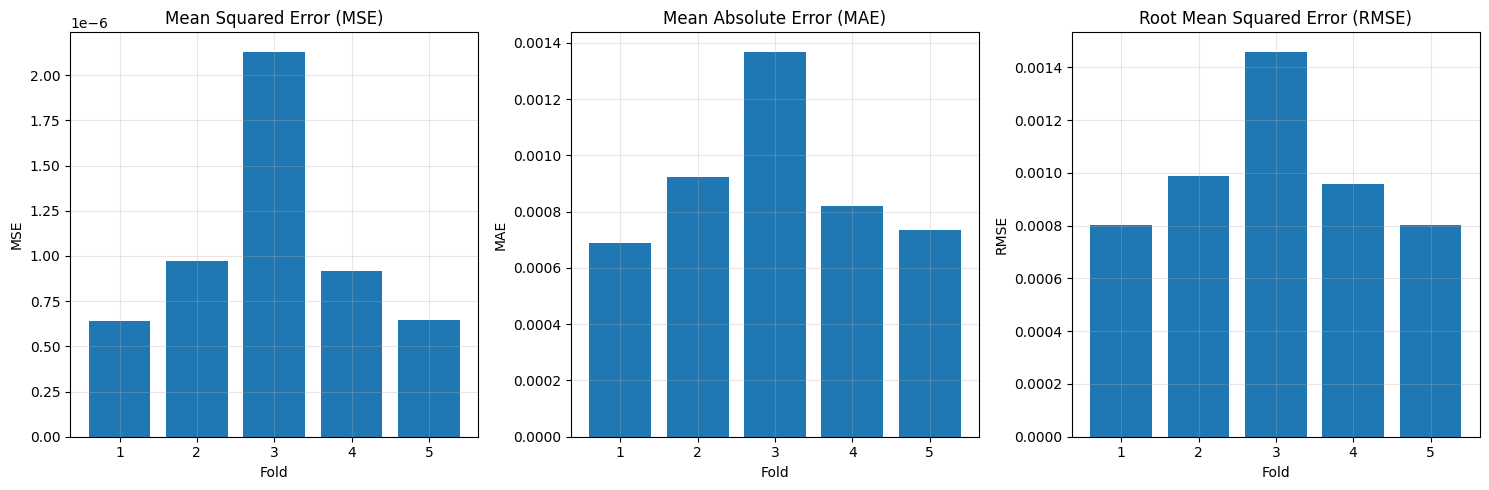


Average Metrics Across Folds:
MSE : 0.0000 ± 0.0000
MAE : 0.0009 ± 0.0002
RMSE: 0.0010 ± 0.0002


In [ ]:
import numpy as np

# Compute mean across folds
mean_train_mse = np.mean(train_mse_list, axis=0)
mean_val_mse = np.mean(val_mse_list, axis=0)
mean_train_mae = np.mean(train_mae_list, axis=0)
mean_val_mae = np.mean(val_mae_list, axis=0)
mean_train_rmse = np.mean(train_rmse_list, axis=0)
mean_val_rmse = np.mean(val_rmse_list, axis=0)

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.plot(epochs_range, mean_train_mse, label="Train MSE")
plt.plot(epochs_range, mean_val_mse, label="Val MSE")
plt.title("Mean Squared Error (MSE)")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs_range, mean_train_mae, label="Train MAE")
plt.plot(epochs_range, mean_val_mae, label="Val MAE")
plt.title("Mean Absolute Error (MAE)")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs_range, mean_train_rmse, label="Train RMSE")
plt.plot(epochs_range, mean_val_rmse, label="Val RMSE")
plt.title("Root Mean Squared Error (RMSE)")
plt.xlabel("Epochs")
plt.ylabel("RMSE")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# The metrics we have are final values per fold, not per epoch
# So let's create a bar plot to show the metrics across folds

# Set up the plot
plt.figure(figsize=(15, 5))

# Plot MSE
plt.subplot(1, 3, 1)
plt.bar(range(1, len(val_mse_list) + 1), val_mse_list)
plt.title("Mean Squared Error (MSE)")
plt.xlabel("Fold")
plt.ylabel("MSE")
plt.grid(True, alpha=0.3)

# Plot MAE
plt.subplot(1, 3, 2)
plt.bar(range(1, len(val_mae_list) + 1), val_mae_list)
plt.title("Mean Absolute Error (MAE)")
plt.xlabel("Fold")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)A

# Plot RMSE
plt.subplot(1, 3, 3)
plt.bar(range(1, len(val_rmse_list) + 1), val_rmse_list)
plt.title("Root Mean Squared Error (RMSE)")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print average metrics
print("\nAverage Metrics Across Folds:")
print(f"MSE : {np.mean(val_mse_list):.4f} ± {np.std(val_mse_list):.4f}")
print(f"MAE : {np.mean(val_mae_list):.4f} ± {np.std(val_mae_list):.4f}")
print(f"RMSE: {np.mean(val_rmse_list):.4f} ± {np.std(val_rmse_list):.4f}")